In [9]:
import matplotlib.pyplot as plt

In [10]:
class PMSM:
		def __init__(self, R, L, lambda_m, np, J, B, dt):
			self.R        = R
			self.L        = L
			self.lambda_m = lambda_m
			self.np       = np
			self.J        = J
			self.B        = B

			self.omega    = 0
			self.theta    = 0
			self.id       = 0
			self.iq       = 0
			self.te       = 0

			self.dt       = dt


		def step(self, vd, vq, Tl):
			Te        = 1.5 * self.np * (self.lambda_m * self.iq)
			did_dt    = vd / self.L - self.R * self.id / self.L + self.omega * self.id
			diq_dt    = vq / self.L - self.R * self.iq / self.L - self.omega * (self.iq - self.lambda_m / self.L)

			domega_dt = (Te - Tl - self.B * self.omega) / self.J
			dtheta_dt    = self.omega

			self.id    = self.id + did_dt * self.dt
			self.iq    = self.iq + diq_dt * self.dt
			self.omega = self.omega + domega_dt * self.dt
			self.theta = self.theta + dtheta_dt * self.dt
			self.te    = Te

			return self.id, self.iq, self.omega, self.theta, self.te

In [11]:
class PI_Regler:
		def __init__(self, Kp, Ki, dt):
			self.Kp = Kp
			self.Ki = Ki
			self.dt = dt
			self.integral = 0
			self.output = 0

		def step(self, input, ref):
			error = ref - input
			self.integral = self.integral + error * self.dt
			self.output   = self.Kp * error + self.Ki * self.integral

			return self.output

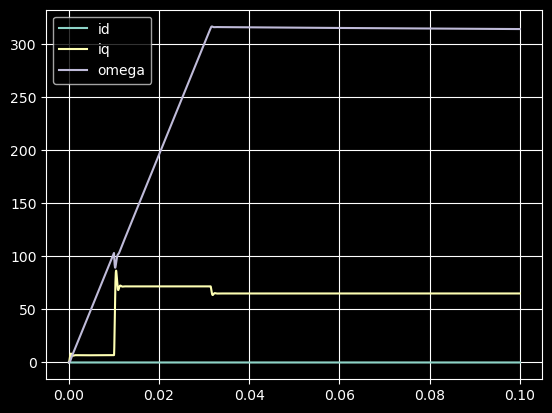

In [12]:
timeInterval = 1e-6
pmsmModel   = PMSM(R=0.112915, L=1.625e-3, lambda_m=2.5707, np=4, J=0.01, B=0.01, dt=timeInterval)
speedRegler = PI_Regler(Kp=6, Ki=23, dt=timeInterval)
idRegler    = PI_Regler(Kp=10, Ki=20, dt=timeInterval)
iqRegler    = PI_Regler(Kp=10, Ki=20, dt=timeInterval)

omega, id, iq  = 0.0, 0.0, 0.0
omega_ref_max  = 314.16
omega_ref      = 0.0

iterTimes      = 100000

id_records, iq_records, speed_records, time_sequence    = [], [], [], []

for i in range(iterTimes):
	if omega_ref < omega_ref_max:
		omega_ref += 0.01
	iq_ref = speedRegler.step(omega, omega_ref)
	vd     = idRegler.step(id, 0)
	vq     = iqRegler.step(iq, iq_ref)
	if i < 10000:
		Tl = 0
	else:
		Tl = 1000
	id, iq, omega, theta, te = pmsmModel.step(vd, vq, Tl=Tl)

	id_records.append(id)
	iq_records.append(iq)
	speed_records.append(omega)
	time_sequence.append(i * pmsmModel.dt)

plt.plot(time_sequence, id_records, label='id')
plt.plot(time_sequence, iq_records, label='iq')
plt.plot(time_sequence, speed_records, label='omega')
plt.legend()
plt.grid()
plt.show()
